#  E-COMMERCE SALES  DATA ANALYSIS USING PANDAS



# INTRODUCTION

## In today’s competitive business environment, data-driven decision making plays a major role in improving sales performance, customer satisfaction, and operational efficiency. E-commerce companies generate large volumes of transactional data every day, and analyzing this data can help businesses identify trends, customer purchasing behavior, revenue patterns, and product performance.

## This Exploratory Data Analysis (EDA) project focuses on analyzing an E-commerce Sales Analytics dataset using Python libraries such as Pandas, NumPy, Matplotlib, and Seaborn. The main objective of the project is to clean, process, and visualize the sales data to uncover meaningful insights that can support business decisions.

## The analysis includes examining sales trends over time, identifying top-performing product categories, studying customer purchasing patterns, evaluating regional performance, and understanding revenue distribution across different payment methods and product segments. Various statistical summaries and visualizations are used to simplify complex data and present findings in a clear and understandable manner.

## Through this project, important data analysis skills such as data cleaning, handling missing values, feature engineering, grouping and aggregation, and visualization techniques are applied. The project also demonstrates how EDA can transform raw data into actionable insights that help organizations improve strategy and performance.

## Overall, this EDA project highlights the importance of data analytics in the e-commerce industry and provides a practical understanding of how real-world business data can be analyzed effectively using Python.

# 1. DATA COLLECTION

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv(r"C:\Users\VIJAY VINSON\OneDrive\data science\dataset\csv\ecommerce_sales_analytics.csv")
print(df)

      order_id order_date  customer_id product_category region  quantity  \
0        10001   1/1/2022         1102           Beauty  South         7   
1        10002   1/2/2022         1435         Clothing  South         7   
2        10003   1/3/2022         1860           Beauty   East         3   
3        10004   1/4/2022         1270      Electronics   West         5   
4        10005   1/5/2022         1106         Clothing   West         5   
...        ...        ...          ...              ...    ...       ...   
4995     14996   9/5/2035         1289         Clothing   West         2   
4996     14997   9/6/2035         1294           Beauty  North         3   
4997     14998   9/7/2035         1450           Beauty   West         3   
4998     14999   9/8/2035         1903      Electronics  South         4   
4999     15000   9/9/2035         1214             Home   East         7   

      unit_price  discount payment_method  delivery_days  customer_rating  \
0         

## first 5 data using head()

In [4]:
df.head(5)

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


## last 5 data using the tail()

In [5]:
df.tail(5)

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
4995,14996,9/5/2035,1289,Clothing,West,2,371.74,0.27,COD,3,2.3,542.74
4996,14997,9/6/2035,1294,Beauty,North,3,553.67,0.14,COD,11,2.2,1428.47
4997,14998,9/7/2035,1450,Beauty,West,3,77.22,0.24,Wallet,6,3.4,176.06
4998,14999,9/8/2035,1903,Electronics,South,4,138.41,0.21,COD,4,2.8,437.38
4999,15000,9/9/2035,1214,Home,East,7,231.58,0.34,COD,5,3.9,1069.90


## checking the wrong format 

In [6]:

data=pd.DataFrame(df)
print(df.dtypes)
print("\n")
# convert date
df['order_date']=pd.to_datetime(df['order_date'])
#  strings convert to category along with correcting space and casesensitive problems
categorical_cols=['product_category','region','payment_method']
for col in categorical_cols:
    df[col]=df[col].str.strip().str.title().astype('category')


order_id              int64
order_date           object
customer_id           int64
product_category     object
region               object
quantity              int64
unit_price          float64
discount            float64
payment_method       object
delivery_days         int64
customer_rating     float64
revenue             float64
dtype: object




## checking all the columns and dtypes

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          5000 non-null   int64         
 1   order_date        5000 non-null   datetime64[ns]
 2   customer_id       5000 non-null   int64         
 3   product_category  5000 non-null   category      
 4   region            5000 non-null   category      
 5   quantity          5000 non-null   int64         
 6   unit_price        5000 non-null   float64       
 7   discount          5000 non-null   float64       
 8   payment_method    5000 non-null   category      
 9   delivery_days     5000 non-null   int64         
 10  customer_rating   5000 non-null   float64       
 11  revenue           5000 non-null   float64       
dtypes: category(3), datetime64[ns](1), float64(4), int64(4)
memory usage: 366.9 KB


# 2. DATA CLEANING
## checking the null valves 

In [8]:


df.isnull().sum()

order_id            0
order_date          0
customer_id         0
product_category    0
region              0
quantity            0
unit_price          0
discount            0
payment_method      0
delivery_days       0
customer_rating     0
revenue             0
dtype: int64

## checking the duplicated values

In [9]:
print(f"total duplicated values : {df.duplicated().sum()}")

total duplicated values : 0


## checking the outliers


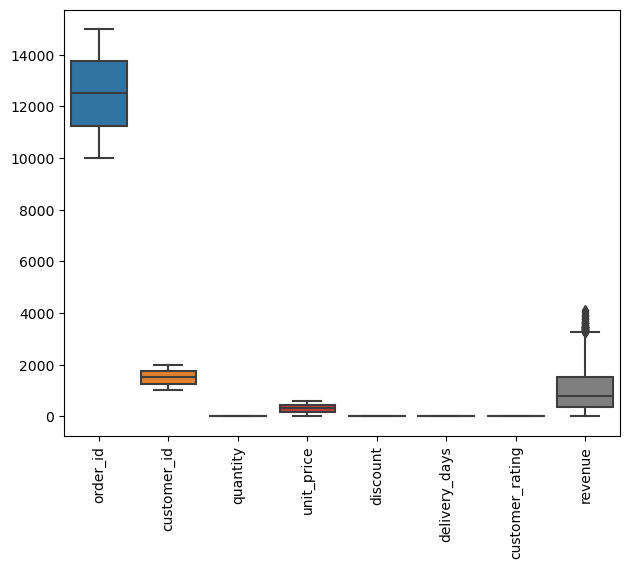

In [10]:
sns.boxplot(data=df)
plt.tight_layout()
plt.xticks(rotation=90)
plt.show()

## REMOVING OUTLINERS USING IQR (interquartile range )

In [11]:
target_col = 'revenue'


# calculate q1 (25 th percentile) ,q3 (75th percentile) and iqr

Q1=df[target_col].quantile(0.25)
Q3=df[target_col].quantile(0.75)
IQR=Q3-Q1

# define lower and upper bounds to identify outliers
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# filter outliers
df_final = df[(df[target_col] >= lower_limit) & (df[target_col] <= upper_limit)]
print(f"Original rows: {len(df)}")
print(f"Rows after removing outliers: {len(df_final)}")

Original rows: 5000
Rows after removing outliers: 4933


## AFTER RESULT OF REMOVING THE OUTLIERS FROM THE REVENUE 

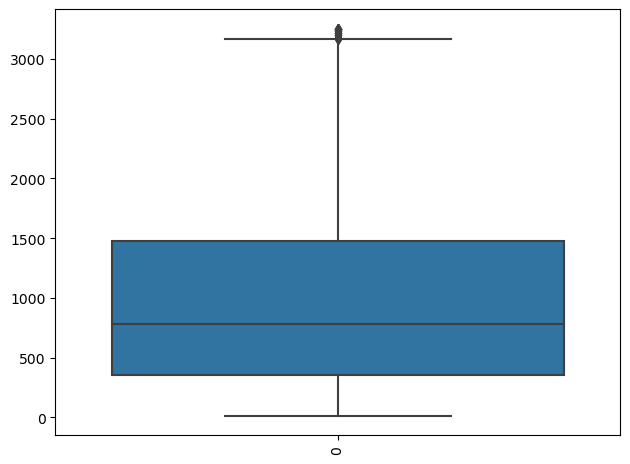

In [12]:
sns.boxplot(data=df_final['revenue'])
plt.tight_layout()
plt.xticks(rotation=90)
plt.show()

## checking the missing values

In [13]:
print(df.isna().sum())

order_id            0
order_date          0
customer_id         0
product_category    0
region              0
quantity            0
unit_price          0
discount            0
payment_method      0
delivery_days       0
customer_rating     0
revenue             0
dtype: int64


## QUESTIONS

product_category
Electronics    1829899.22
Clothing       1531931.72
Home            982083.92
Beauty          765860.88
Name: revenue, dtype: float64


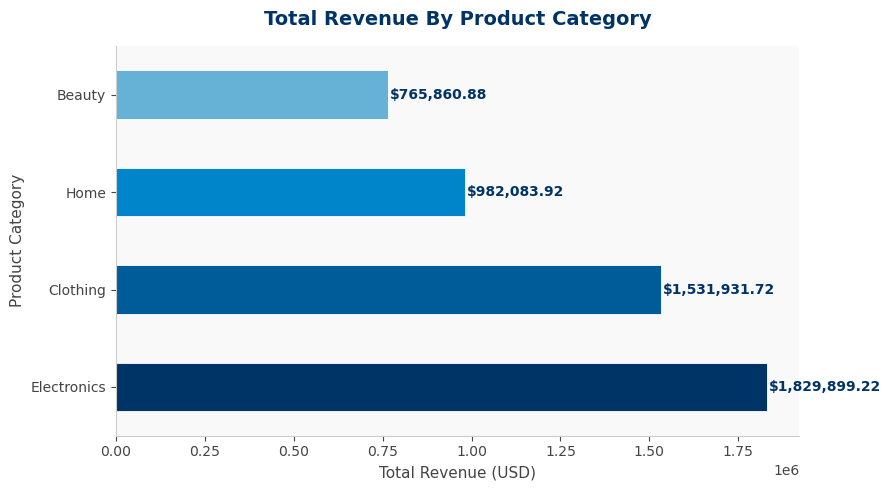

In [14]:
# 1.Which products categories generate the highest total revenue?
revenue_by_category=df.groupby('product_category')['revenue'].sum().sort_values(ascending=False).head(10)
print(revenue_by_category)
# Finance-standard: Navy → Steel Blue (Bloomberg / McKinsey style)
colors = ['#003366', '#005B99', '#0085CA', '#66B2D6']

fig, ax = plt.subplots(figsize=(9, 5))

revenue_by_category.plot(kind='barh',color=colors,edgecolor='white',linewidth=0.6,ax=ax)

# Value labels at end of each bar
for i, val in enumerate(revenue_by_category):
    ax.text(val + 5000, i, f'${val:,.2f}', va='center',fontsize=10, fontweight='bold', color='#003366')

# Styling
ax.set_title('Total Revenue By Product Category',
             fontsize=14, fontweight='bold', color='#003366', pad=15)
ax.set_xlabel('Total Revenue (USD)', fontsize=11, color='#444444')
ax.set_ylabel('Product Category', fontsize=11, color='#444444')
ax.tick_params(colors='#444444')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')
ax.set_facecolor('#F9F9F9')
fig.patch.set_facecolor('#FFFFFF')

plt.tight_layout()
plt.show()

product_category
Electronics    7109
Clothing       6171
Home           3949
Beauty         2995
Name: quantity, dtype: int64


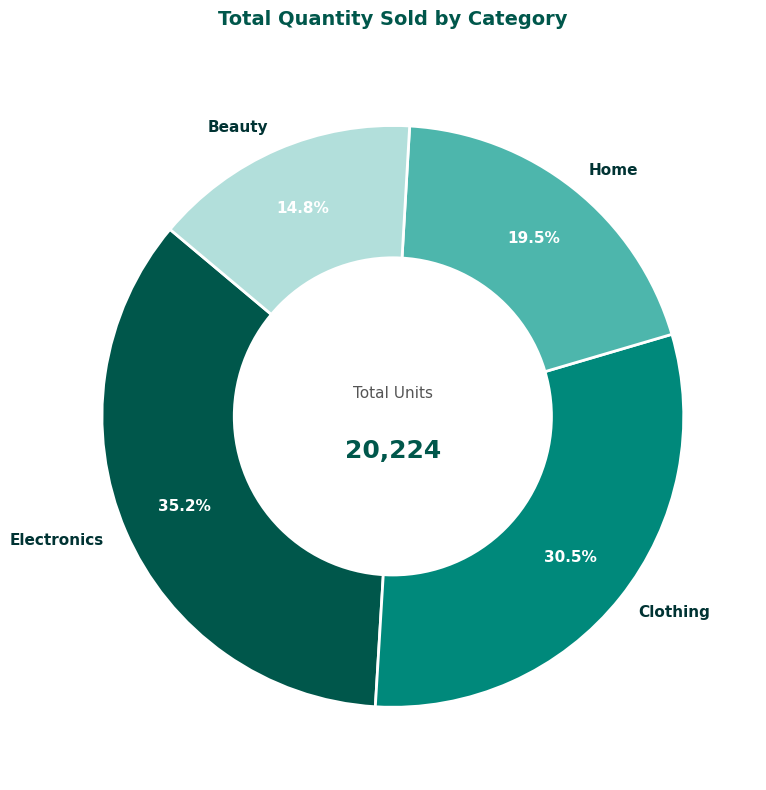

In [15]:
# 2. What is the total quantity sold in each category?
qty_by_category=df.groupby('product_category')['quantity'].sum().sort_values(ascending=False)
print(qty_by_category)
colors = ['#00574B', '#00897B', '#4DB6AC', '#B2DFDB']
fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(qty_by_category,labels=qty_by_category.index,autopct='%1.1f%%',startangle=140,colors=colors,wedgeprops={'edgecolor': 'white', 'linewidth': 2},pctdistance=0.78,labeldistance=1.08)

# Style percentage labels
for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

# Style category labels
for text in texts:
    text.set_fontsize(11)
    text.set_color('#003333')
    text.set_fontweight('bold')

# Draw center hole — converts pie to donut
centre_circle = plt.Circle((0, 0), 0.55, fc='white')
ax.add_artist(centre_circle)

# Center label — total quantity
total = qty_by_category.sum()
ax.text(0, 0.08, 'Total Units', ha='center', va='center',fontsize=11, color='#555555')
ax.text(0, -0.12, f'{total:,}', ha='center', va='center',fontsize=18, fontweight='bold', color='#00574B')

# Title
ax.set_title('Total Quantity Sold by Category',fontsize=14, fontweight='bold', color='#00574B', pad=20)

plt.tight_layout()
plt.show()

product_category
Electronics    314.902656
Home           306.257730
Beauty         304.712891
Clothing       304.010901
Name: unit_price, dtype: float64


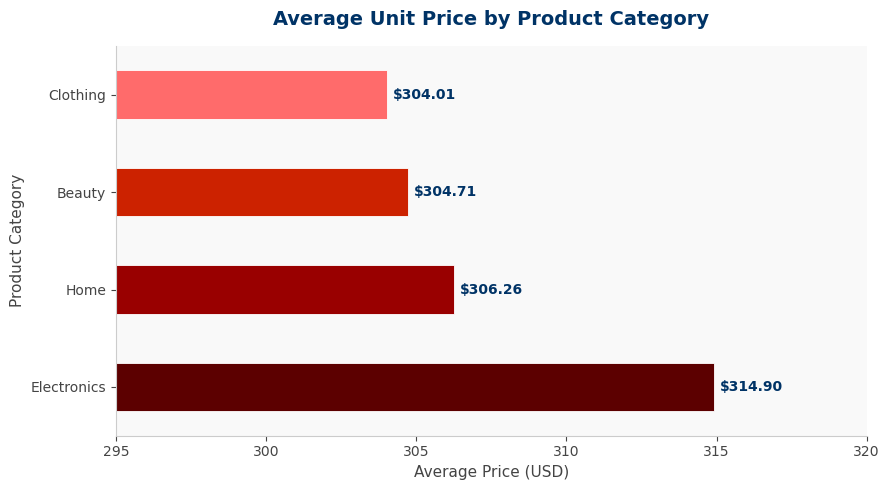

In [16]:
# 3. What is the average price of products in each category?
avg_price=df.groupby('product_category')['unit_price'].mean().sort_values(ascending=False)
print(avg_price)
colors = ['#5C0000', '#990000', '#CC2200', '#FF6B6B']
fig,ax=plt.subplots(figsize=(9,5))
bars=avg_price.plot(kind='barh',color=colors,edgecolor='white',linewidth=0.6,ax=ax)

# Zoom in to highlight differences
ax.set_xlim(295, 320)

# Add value labels at end of each bar
for i, (val, name) in enumerate(zip(avg_price, avg_price.index)):
    ax.text(val + 0.2, i, f'${val:,.2f}', va='center',
            fontsize=10, fontweight='bold', color='#003366')

# Styling
ax.set_title('Average Unit Price by Product Category',
             fontsize=14, fontweight='bold', color='#003366', pad=15)
ax.set_xlabel('Average Price (USD)', fontsize=11, color='#444444')
ax.set_ylabel('Product Category', fontsize=11, color='#444444')
ax.tick_params(colors='#444444')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')
ax.set_facecolor('#F9F9F9')
fig.patch.set_facecolor('#FFFFFF')

plt.tight_layout()
plt.show()

product_category
Beauty         1059.281992
Electronics    1029.768835
Home           1013.502497
Clothing       1000.608570
Name: revenue, dtype: float64


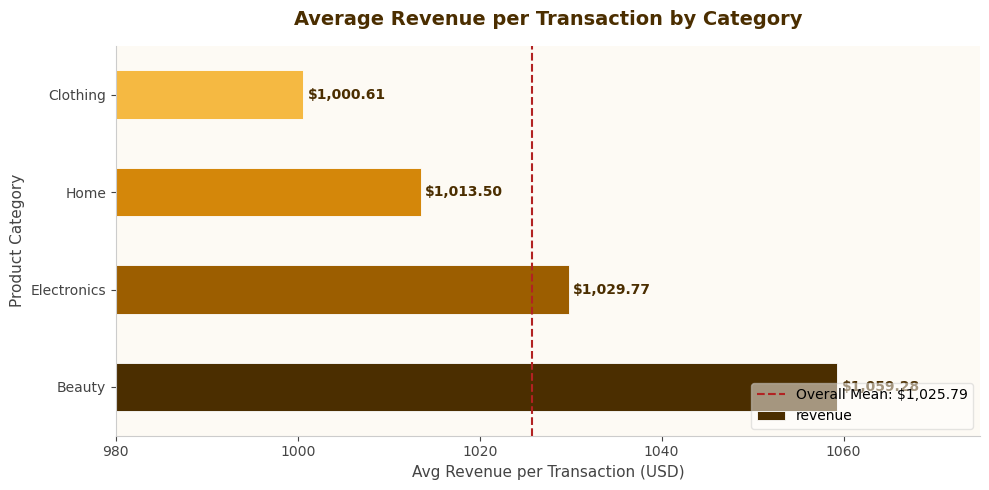

In [17]:
# 4. Which category has the highest average revenue per transaction?
avg_revenue=df.groupby('product_category')['revenue'].mean().sort_values(ascending=False)
print(avg_revenue)
# Finance-standard: Gold/Amber palette — used in revenue & performance reports
colors = ['#4B2E00', '#9C5E00', '#D4870A', '#F5B942']  # Dark Amber → Gold gradient

fig, ax = plt.subplots(figsize=(10, 5))

avg_revenue.plot(kind='barh',color=colors,edgecolor='white',linewidth=0.6,ax=ax)

# Zoom in to show differences clearly
ax.set_xlim(980, 1075)

# Overall mean reference line
overall_mean = avg_revenue.mean()
ax.axvline(overall_mean, color='#B22222', linestyle='--',linewidth=1.5, label=f'Overall Mean: ${overall_mean:,.2f}')

# Value labels
for i, val in enumerate(avg_revenue):ax.text(val + 0.5, i, f'${val:,.2f}', va='center',fontsize=10, fontweight='bold', color='#4B2E00')

# Legend
ax.legend(fontsize=10, loc='lower right', framealpha=0.5)

# Styling
ax.set_title('Average Revenue per Transaction by Category', fontsize=14, fontweight='bold', color='#4B2E00', pad=15)
ax.set_xlabel('Avg Revenue per Transaction (USD)', fontsize=11, color='#444444')
ax.set_ylabel('Product Category', fontsize=11, color='#444444')
ax.tick_params(colors='#444444')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')
ax.set_facecolor('#FDFAF4')   # Warm off-white background
fig.patch.set_facecolor('#FFFFFF')

plt.tight_layout()
plt.show()


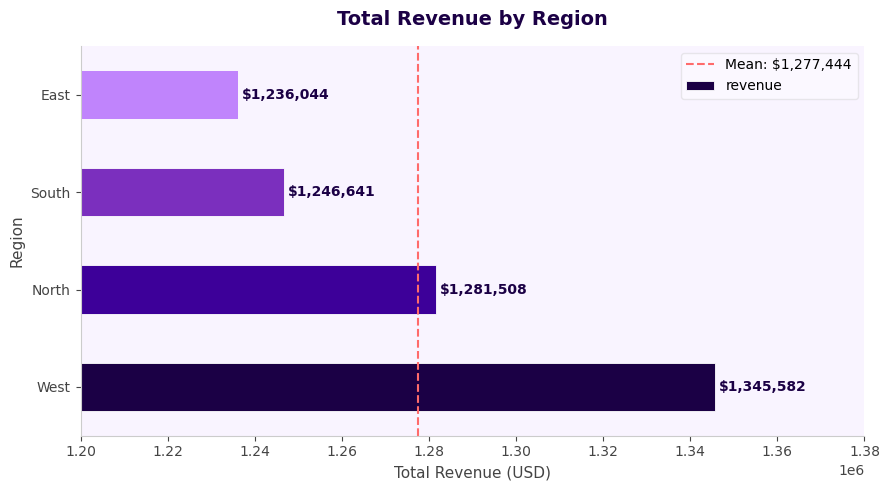

In [18]:
# 5. Which regions generate the highest total revenue?
region_revenue=df.groupby('region')['revenue'].sum().sort_values(ascending=False)
# Professional: Deloitte Purple palette — perfect for regional/geographic analysis
colors = ['#1B0045', '#3D0099', '#7B2FBE', '#C084FC']

fig, ax = plt.subplots(figsize=(9, 5))

region_revenue.plot( kind='barh',color=colors,edgecolor='white',linewidth=0.6,ax=ax)

# Zoom in to highlight differences
ax.set_xlim(1200000, 1380000)

# Value labels
for i, val in enumerate(region_revenue):
    ax.text(val + 1000, i, f'${val:,.0f}', va='center',fontsize=10, fontweight='bold', color='#1B0045')

# Overall mean reference line
mean_val = region_revenue.mean()
ax.axvline(mean_val, color='#FF6B6B', linestyle='--',
linewidth=1.5, label=f'Mean: ${mean_val:,.0f}')

ax.legend(fontsize=10, framealpha=0.4)

# Styling
ax.set_title('Total Revenue by Region',
             fontsize=14, fontweight='bold', color='#1B0045', pad=15)
ax.set_xlabel('Total Revenue (USD)', fontsize=11, color='#444444')
ax.set_ylabel('Region', fontsize=11, color='#444444')
ax.tick_params(colors='#444444')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')
ax.set_facecolor('#F9F4FF')   # Soft purple-tinted background
fig.patch.set_facecolor('#FFFFFF')

plt.tight_layout()
plt.show()


highest region average revenue:region
West     1043.896168
South    1031.987500
East     1007.371011
North    1004.316967
Name: revenue, dtype: float64


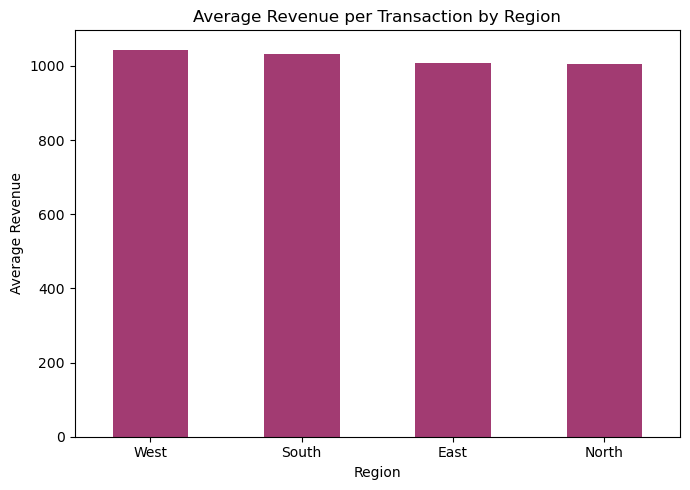

In [19]:
# 6. Which region has the highest average revenue per transaction?
avg_revenue_region=df.groupby('region')['revenue'].mean().sort_values(ascending=False)
print(f"highest region average revenue:{avg_revenue_region}")

avg_revenue_region.plot(kind='bar', color='#A23B72', figsize=(7, 5))

plt.title('Average Revenue per Transaction by Region')
plt.xlabel('Region')
plt.ylabel('Average Revenue')
plt.xticks(rotation=0)  # keeps region labels straight
plt.tight_layout()
plt.show()


region                 East      North      South       West
product_category                                            
Beauty            174909.11  186213.32  191073.98  213664.47
Clothing          402582.60  364659.43  348363.14  416326.55
Electronics       411803.35  472450.93  487055.68  458589.26
Home              246749.17  258184.77  220148.10  257001.88


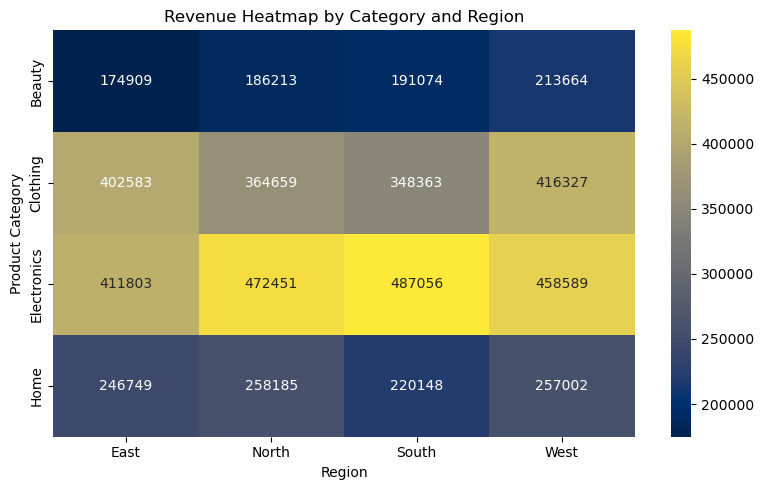

In [20]:
# 7.How does revenue vary across categories and regions?
pivot=pd.pivot_table( df,values='revenue',index='product_category',columns='region',aggfunc='sum')
print(pivot)
plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='cividis')

plt.title('Revenue Heatmap by Category and Region')
plt.xlabel('Region')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()

customer_id
1000    6905.58
1001    3959.74
1002    1579.67
1003    2304.44
1004    6073.85
         ...   
1995    4082.06
1996    7053.98
1997    6466.30
1998    7213.69
1999     465.53
Name: revenue, Length: 989, dtype: float64


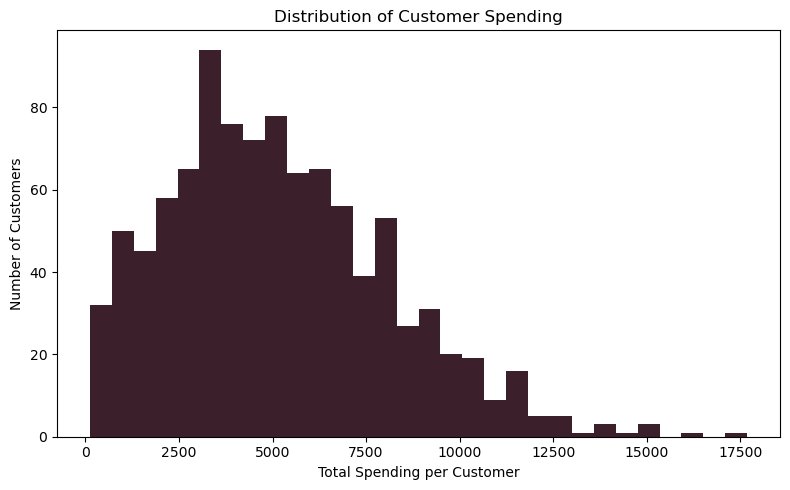

In [21]:
# 9. What is the average spending per customer?
customer_spending=df.groupby('customer_id')['revenue'].sum()
print(customer_spending)
customer_spending.plot(kind='hist', bins=30, color='#3B1F2B', figsize=(8, 5))

plt.title('Distribution of Customer Spending')
plt.xlabel('Total Spending per Customer')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

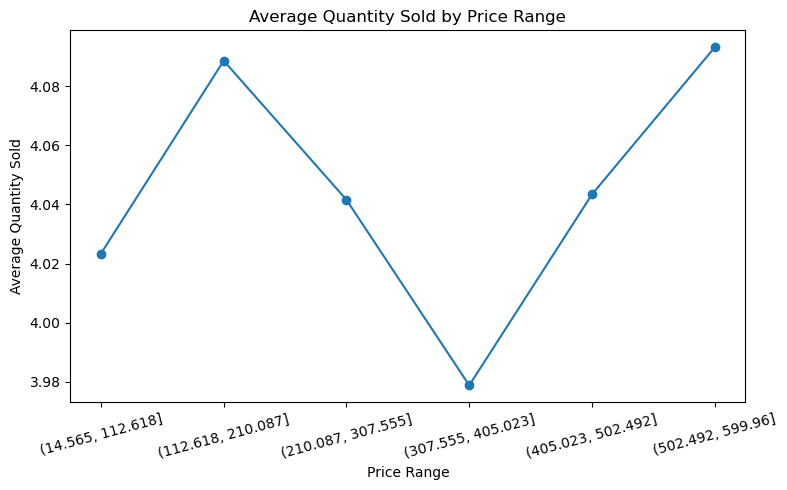

In [34]:
# 10 Is there a relationship between price and quantity sold?
# Create price bins
df['price_range'] = pd.cut(df['unit_price'], bins=6)

# Average quantity for each price range
avg_qty = df.groupby('price_range')['quantity'].mean()

plt.figure(figsize=(8,5))
avg_qty.plot(marker='o')

plt.title('Average Quantity Sold by Price Range')
plt.xlabel('Price Range')
plt.ylabel('Average Quantity Sold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

                  quantity     revenue
product_category                      
Electronics           7109  1829899.22
Clothing              6171  1531931.72
Home                  3949   982083.92
Beauty                2995   765860.88


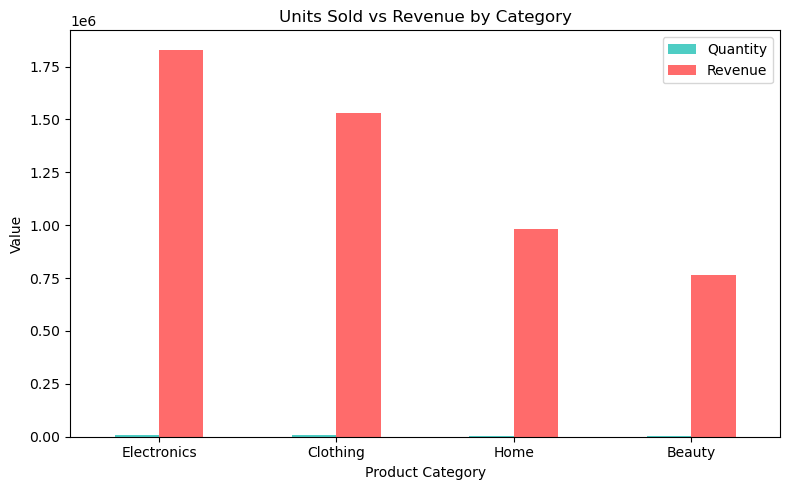

In [23]:
# 11. Which category sells the most units but generates less revenue?
q11=df.groupby('product_category').agg({'quantity': 'sum','revenue': 'sum'}).sort_values(by='quantity', ascending=False)
print(q11)
q11.plot(kind='bar', figsize=(8, 5), color=['#4ECDC4', '#FF6B6B'])

plt.title('Units Sold vs Revenue by Category')
plt.xlabel('Product Category')
plt.ylabel('Value')
plt.xticks(rotation=0)
plt.legend(['Quantity', 'Revenue'])
plt.tight_layout()
plt.show()

                  quantity     revenue
product_category                      
Electronics           7109  1829899.22
Clothing              6171  1531931.72
Home                  3949   982083.92
Beauty                2995   765860.88


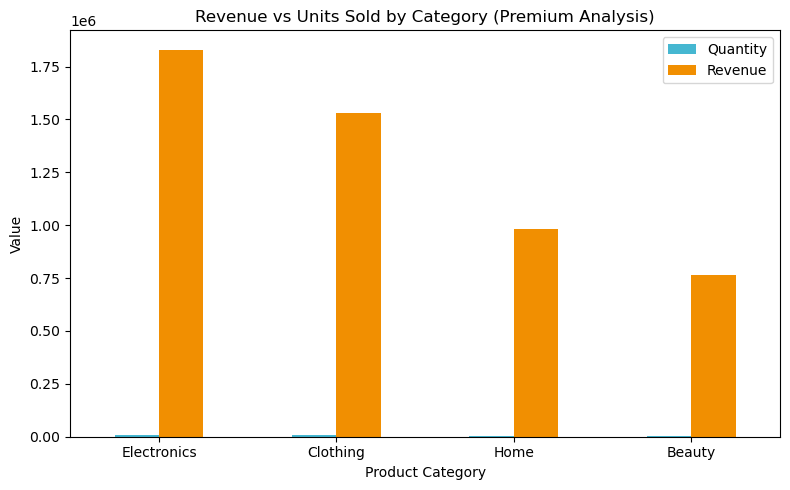

In [24]:
#12. Which category generates high revenue with fewer sales (premium)?
q12=df.groupby('product_category').agg({'quantity': 'sum','revenue': 'sum'}).sort_values(by='revenue', ascending=False)
print(q12)
q12.plot(kind='bar', figsize=(8, 5), color=['#45B7D1', '#F18F01'])

plt.title('Revenue vs Units Sold by Category (Premium Analysis)')
plt.xlabel('Product Category')
plt.ylabel('Value')
plt.xticks(rotation=0)
plt.legend(['Quantity', 'Revenue'])
plt.tight_layout()
plt.show()

product_category
Beauty         867.590231
Clothing       806.210745
Electronics    831.796825
Home           812.271060
Name: revenue, dtype: float64


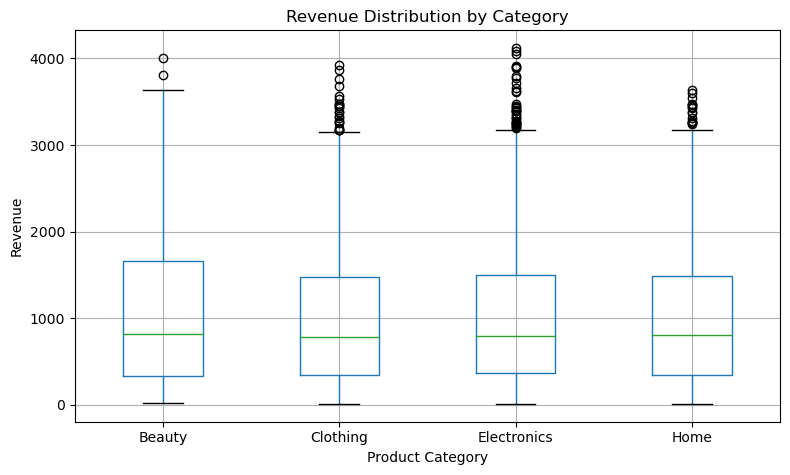

In [25]:
#.13 How consistent is revenue across product categories?
reve_across_pCategory=df.groupby('product_category')['revenue'].std()
print(reve_across_pCategory)
df.boxplot(column='revenue', by='product_category', figsize=(8, 5))

plt.title('Revenue Distribution by Category')
plt.suptitle('')
plt.xlabel('Product Category')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

product_category
Electronics    7109
Clothing       6171
Home           3949
Beauty         2995
Name: quantity, dtype: int64


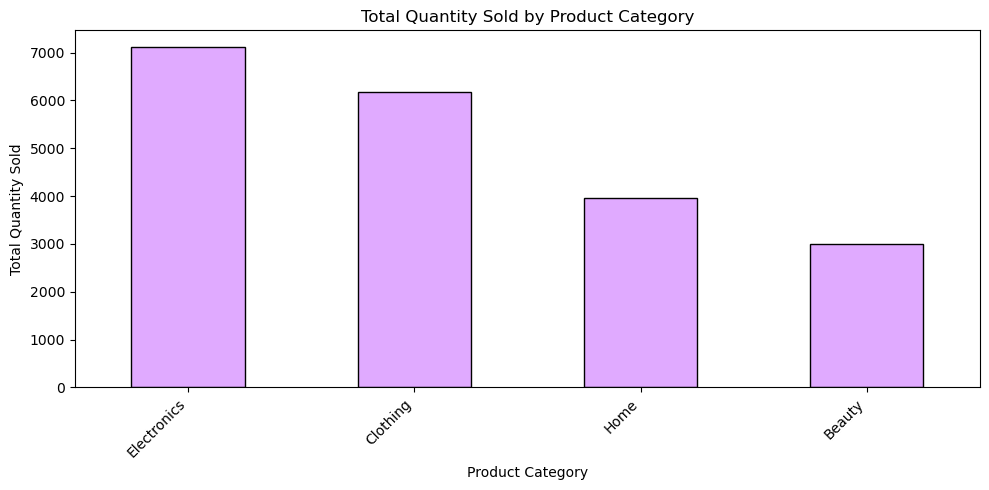

In [26]:
# 14 Which category has the highest total quantity sold?
total_quantity_sold=df.groupby('product_category')['quantity'].sum().sort_values(ascending=False).head(10)
print(total_quantity_sold)
total_quantity_sold.plot(kind='bar', figsize=(10, 5), color='#E0AAFF', edgecolor='black')
plt.title('Total Quantity Sold by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

product_category
Beauty         14.988151
Clothing       29.980410
Electronics    35.811733
Home           19.219707
Name: revenue, dtype: float64


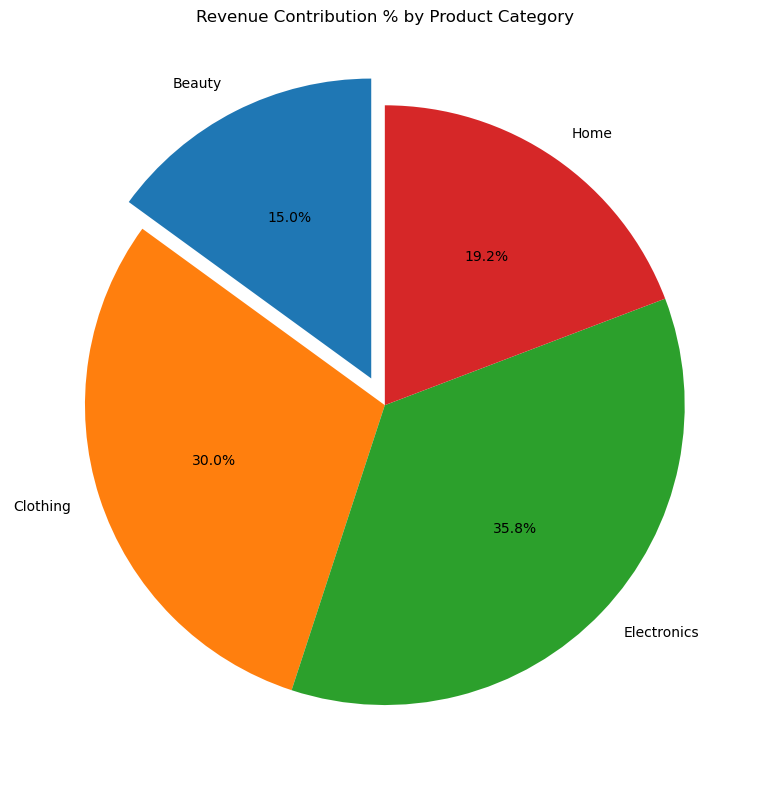

In [27]:
# 15 What is the revenue contribution percentage of each category?
category_sales=df.groupby('product_category')['revenue'].sum()
revenue_percent=(category_sales / category_sales.sum())*100
print(revenue_percent)
# Create explode list dynamically based on number of categories
explode = [0.1] + [0] * (len(revenue_percent) - 1)  # pulls out the 1st (highest) slice

plt.figure(figsize=(8, 8))
plt.pie(revenue_percent, explode=explode,autopct='%1.1f%%', labels=revenue_percent.index,startangle=90)
plt.title('Revenue Contribution % by Product Category')
plt.tight_layout()
plt.show()

# Conclusion

### This EDA explored an e-commerce dataset of **5000 orders** across 4 product categories and 4 regions.

## Key Findings

### - Electronics dominates both in revenue and units sold, making it the most valuable and popular category
### - West region contributes the highest revenue among all regions
### - Card is the most preferred payment method by customers
### - Average customer rating is 2.97 out of 5, which is below average and suggests room for improvement in product quality or service
### - Average delivery time is 6 days, which may be contributing to the low customer ratings
### - Price and quantity showed no strong relationship, meaning customers buy regardless of price point
### - Beauty and Clothing generate lower revenue despite reasonable sales volume, indicating lower price points

## Overall
### Electronics drives the business, but improving delivery speed and customer satisfaction across all categories could significantly boost ratings and repeat purchases.